In [1]:
import h5py 
import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1" # quite nice life hack
import torch
import torchvision
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from skimage.measure import regionprops_table, regionprops
import pandas as pd
from tqdm.auto import tqdm

PyTorch version: 2.8.0
Torchvision version: 0.23.0
CUDA is available: False


In [2]:
# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "\ngive numerically different outputs and sometimes degraded performance on MPS. "
        "\nSee e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )

using device: mps

Support for MPS devices is preliminary. SAM 2 is trained with CUDA and might 
give numerically different outputs and sometimes degraded performance on MPS. 
See e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion.


In [6]:
file_path = "/Volumes/CT-Data/DFG_Benni/Probe4_klein/Probe4_klein.h5"

with h5py.File(file_path, "r") as f:
    print("Keys in the HDF5 file:", list(f.keys()))
    data = f["volume"][1000:1000+1024,600:620,400:400+1024]
    print("Data shape:", data.shape)

Keys in the HDF5 file: ['volume']
Data shape: (1024, 20, 1024)


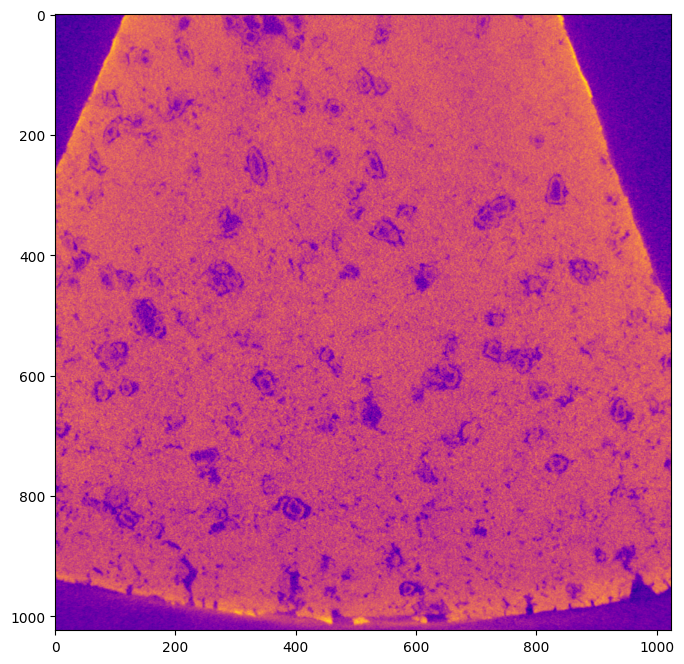

In [9]:
img = data

plt.figure(figsize=(8,8))
plt.imshow(img[:,0,:],cmap="plasma")


In [13]:
img = ((img - img.min()) / (img.max() - img.min()) * 255).astype(np.uint8)

img = img.swapaxes(0,1)

print(img.dtype, img.shape)

uint8 (20, 1024, 1024, 3)


In [ ]:
img = np.stack([img]*3, axis=-1)


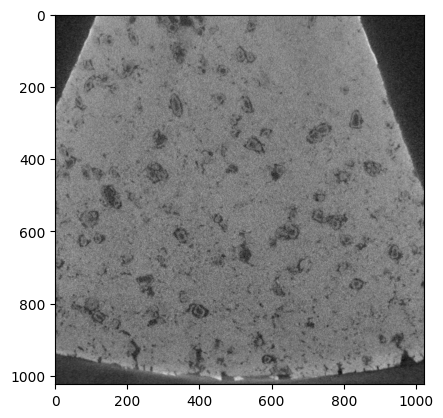

In [14]:
plt.imshow(img[0,:,:])

In [15]:
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator
from sam2.addons import show_anns

# set here your checkpoint path and path to yourmodel cfg
sam2_checkpoint = "../checkpoints/sam2.1_hiera_tiny.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_t.yaml"

sam2 = build_sam2(model_cfg, sam2_checkpoint, device=device, apply_postprocessing=False)

mask_generator = SAM2AutomaticMaskGenerator(
    model=sam2,                 # The preloaded SAM2 model used for automatic segmentation

    points_per_side=64,         # Sampling density of prompt points per image side.
                                # A higher value → more points → denser coverage, better for small or fine structures,
                                # but also slower and more memory-intensive.

    points_per_batch=64,        # Number of sampled points processed simultaneously by the model.
                                # Controls batch size; balance between speed and GPU memory usage.

    pred_iou_thresh=0.1,        # Minimum predicted IoU between the mask and its region proposal
                                # required to keep a candidate. Lower this to retain weaker (small or uncertain) masks.

    min_mask_region_area=10,    # Minimum area (in pixels) for a mask to be kept.
                                # Increasing this removes tiny specks; decreasing it helps keep very small objects.

    box_nms_thresh=0.1,         # Non-Maximum Suppression (NMS) threshold for filtering overlapping boxes.
                                # Lower values make the filter stricter, keeping fewer overlapping regions.

    stability_score_thresh=0.85  # Confidence threshold measuring mask consistency under perturbations.
                                # Lowering this (e.g. 0.7–0.8) retains more masks, especially smaller or noisier ones.
)

In [16]:
print(f"Detection started...")
masks = []
for patch in img:
    mask = mask_generator.generate(patch)
    masks.append(mask)
    print(f"Detection finished...")
    print(f"Detected objects: {len(masks)}")

Detection started...


/Users/christian/Projects/segment-anything-2/sam2/sam2_image_predictor.py:431: UserWarning: cannot import name '_C' from 'sam2' (/Users/christian/Projects/segment-anything-2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  masks = self._transforms.postprocess_masks(


Detection finished...
Detected objects: 1


KeyboardInterrupt: 

In [ ]:
sorted_masks = sorted(masks, key=lambda x: x["area"])

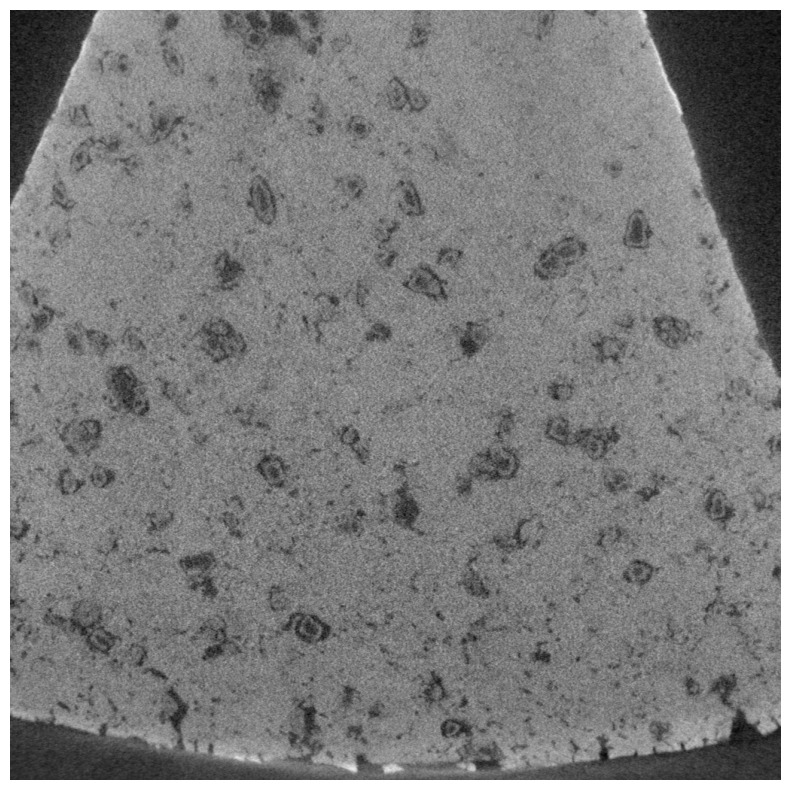

In [77]:
# Display some results
plt.figure(figsize=(20, 10))
plt.imshow(img)
# label_canvas = show_anns(sorted_masks[:-5])
plt.axis('off')
plt.show()

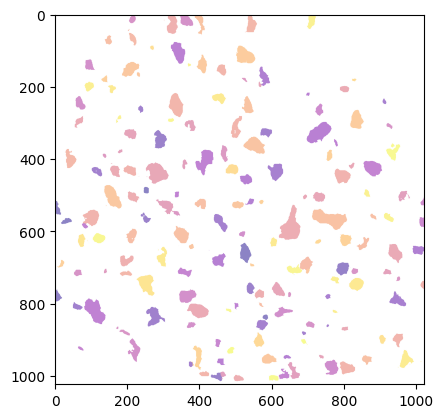

In [71]:
plt.imshow(label_canvas)